In [1]:
import baltic as bt
import pandas as pd

from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from scipy.stats import chisquare
from scipy.stats import chi2_contingency


In [2]:
tree_folder = "host_trees"
clades = ['NA-avian', 'swine', 'human', 'canine', 'equine']

In [3]:
host_trees = {}

for clade in clades:
    
    tree = bt.loadNewick(f"{tree_folder}/{clade}.nwk", absoluteTime= False)
    
    host_trees[f"{clade}"] = tree
    

In [4]:
host_trees

{'NA-avian': <baltic.baltic.tree at 0x10838dba0>,
 'swine': <baltic.baltic.tree at 0x314e5e5f0>,
 'human': <baltic.baltic.tree at 0x31523d990>,
 'canine': <baltic.baltic.tree at 0x315327280>,
 'equine': <baltic.baltic.tree at 0x3154092d0>}

In [5]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in host_trees.keys()}
num_segment_counts = {name: {} for name in host_trees.keys()}
leaf_list = {name: [] for name in host_trees.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in host_trees.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in host_trees.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

In [6]:
gene_segment_counts

{'NA-avian': {'NA': 173,
  'NP': 131,
  'NS': 100,
  'PB1': 111,
  'PB2': 117,
  'MP': 99,
  'PA': 183},
 'swine': {'NA': 59,
  'NP': 93,
  'NS': 93,
  'PB1': 63,
  'PB2': 81,
  'MP': 107,
  'PA': 99},
 'human': {'NA': 2, 'NP': 5, 'NS': 4, 'PB1': 3, 'PB2': 6, 'MP': 3, 'PA': 5},
 'canine': {'NA': 1, 'NP': 2, 'NS': 2, 'PB1': 2, 'PB2': 1, 'MP': 2, 'PA': 1},
 'equine': {'NA': 2, 'NP': 0, 'NS': 2, 'PB1': 1, 'PB2': 0, 'MP': 0, 'PA': 1}}

chi2 statistic: 53.277
degrees of freedom: 24
p-value: 5.318e-04


Host: NA-avian
Chi2 statistic: 53.976
p-value: 7.460062151332144e-10


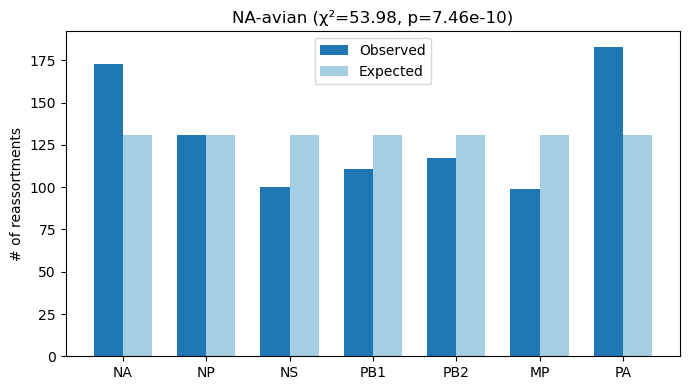


Host: swine
Chi2 statistic: 23.341
p-value: 0.0006899033352857596


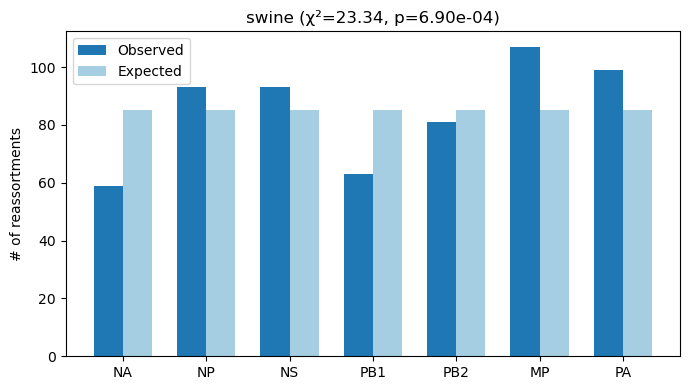


Host: human
Chi2 statistic: 3.0
p-value: 0.8088468305380582


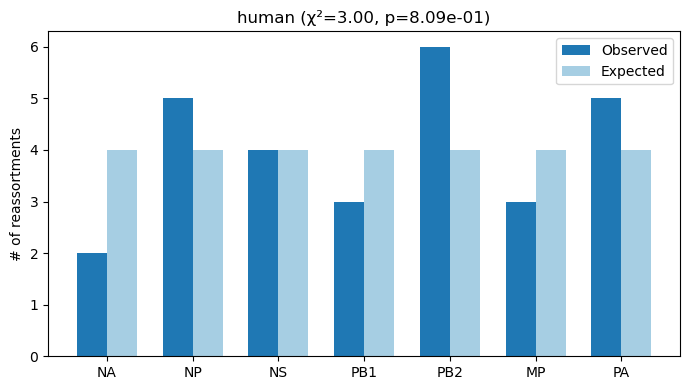


Host: canine
Chi2 statistic: 1.091
p-value: 0.9819301417428591


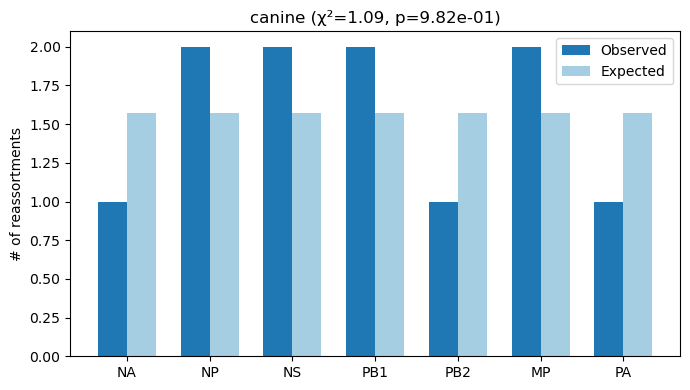


Host: equine
Chi2 statistic: 5.667
p-value: 0.4615459233051791


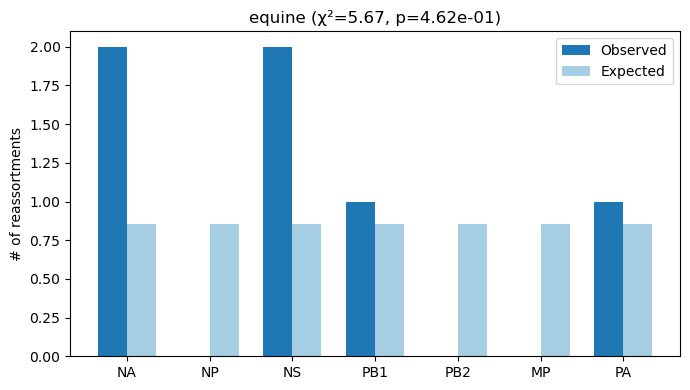

In [7]:
df = pd.DataFrame(gene_segment_counts).T  # rows = hosts, cols = genes
chi2, p, dof, expected = chi2_contingency(df)

# checking if they are independent
print(f"chi2 statistic: {chi2:.3f}")
print(f"degrees of freedom: {dof}")
print(f"p-value: {p:.3e}\n")


for host, counts in gene_segment_counts.items():
    

    observed = list(counts.values())
    genes = list(counts.keys())

    total = sum(observed)
    n_categories = len(observed)
    expected = [total / n_categories] * n_categories

    chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
    
    print(f"\nHost: {host}")
    print("Chi2 statistic:", round(chi2_stat, 3))
    print("p-value:", p_value)

    plt.figure(figsize=(7, 4))
    bar_width = 0.35
    x = range(len(genes))

    plt.bar(x, observed, width=bar_width, label='Observed', color='#1f78b4')
    plt.bar([i + bar_width for i in x], expected, width=bar_width, label='Expected', color='#a6cee3')

    plt.xticks([i + bar_width/2 for i in x], genes)
    plt.ylabel("# of reassortments")
    plt.title(f"{host} (χ²={chi2_stat:.2f}, p={p_value:.2e})")
    plt.legend()
    plt.tight_layout()
    plt.show()